#### Combining the data from trials, and adding some missing columns for ease of use

In [ ]:
possible_dw_values = [12, 4, 9, 3, 6, 2, 3, 1, 14, 2, 7, 1, 3.5, 0.5, 1.75, 0.25, 15, 1, 11.25, 0.75, 7.5, 0.5, 3.75, 0.25]

def closest(val, lst):
    return min(lst, key=lambda x: abs(x - val))

In [ ]:
import pandas as pd
import glob
import os

PPI = 96

folder_path = "./trials"

csv_files = glob.glob(os.path.join(folder_path, "*.csv"))

# Sort files by creation time
csv_files.sort(key=os.path.getctime)

dfs = []
for idx, file in enumerate(csv_files, start=1):
    df = pd.read_csv(file)

    # adding some missing infotmation to the table here

    # to keep it same as in excel sheet
    subject_id = (idx + 1) // 2
    
    df["subject_id"] = subject_id
    df["group_id"] = (subject_id + 1) % 2 

    if file.lower().endswith("touchscreen.csv"):
        df["device"] = 0
    else:
        df["device"] = 1

    # Sketchy fix for my mistake, we saved pixels during trials not inches, sorry ;D
    df["D"] = df["D"].apply(lambda x: closest(x / PPI * 2.54, possible_dw_values))
    df["W"] = df["W"].apply(lambda x: closest(x / PPI * 2.54, possible_dw_values))


    dfs.append(df)

final_df = pd.concat(dfs, ignore_index=True)

output_path = "all_trials.csv"
final_df.to_csv(output_path, index=False)

#### Helpers

In [ ]:

def create_summary(df, group_id=-1):
    if group_id != -1:
        df = df[df["group_id"] == group_id].copy()

    conditions = [
        (12, 4), (9, 3), (6, 2), (3, 1),                    # difficulty 2
        (14, 2), (7, 1), (3.5, 0.5), (1.75, 0.25),          # difficulty 3
        (15, 1), (11.25, 0.75), (7.5, 0.5), (3.75, 0.25)    # difficulty 4
    ]

    
    difficulty_map = [2]*4 + [3]*4 + [4]*4

    cond_df = pd.DataFrame(conditions, columns=["D", "W"])
    cond_df["difficulty_id"] = difficulty_map

    grouped_mean_df = (
        df
        .groupby(["D", "W"]).agg(MT_mean=("MT", "mean"), error_rate=("error", "mean"))
        .reset_index()
    )
        
    merged = grouped_mean_df.merge(cond_df, on=["D","W"], how="left")
    
    merged = merged[["D", "W", "difficulty_id", "MT_mean", "error_rate"]]
    return merged

In [70]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_summary(df):
    plt.figure(figsize=(8,5))
    sns.scatterplot(
        data=df,
        x="difficulty_id",
        y="MT_mean",
        hue="difficulty_id",
        palette="viridis",
        s=100
    )
    plt.xlabel("Difficulty")
    plt.ylabel("Mean Movement Time (ms)")
    plt.title("Mean Movement Time vs Difficulty")
    plt.legend(title="Difficulty")
    plt.show()
    
    plt.figure(figsize=(8,5))
    sns.scatterplot(
        data=df,
        x="difficulty_id",
        y="error_rate",
        hue="difficulty_id",
        palette="viridis",
        s=100
    )
    plt.xlabel("Difficulty")
    plt.ylabel("Error Rate")
    plt.title("Error Rate vs Difficulty")
    plt.ylim(0,1)
    plt.legend(title="Difficulty")
    plt.show()
    
    plt.figure(figsize=(8,6))
    sns.scatterplot(
        data=df,
        x="D",
        y="W",
        hue="difficulty_id",
        palette="viridis",
        s=200
    )
    plt.xlabel("D (cm)")
    plt.ylabel("W (cm)")
    plt.title("Conditions: D vs W colored by Difficulty")
    plt.legend(title="Difficulty")
    plt.show()

### Groups combined

In [79]:
all_trials = pd.read_csv("./all_trials.csv")

combined_summary = create_summary(all_trials)
combined_summary

,D,W,difficulty_id,MT_mean,error_rate
0,1.75,0.25,3,940.967284,0.600000
1,3.00,1.00,2,731.206681,0.216667
2,3.50,0.50,3,862.917467,0.441667
3,3.75,0.25,4,972.321413,0.591667
4,6.00,2.00,2,683.720718,0.025000
5,7.00,1.00,3,821.277761,0.216667
6,7.50,0.50,4,896.490596,0.466667
7,9.00,3.00,2,693.544483,0.033333
8,11.25,0.75,4,884.053063,0.308333
9,12.00,4.00,2,696.518938,0.041667


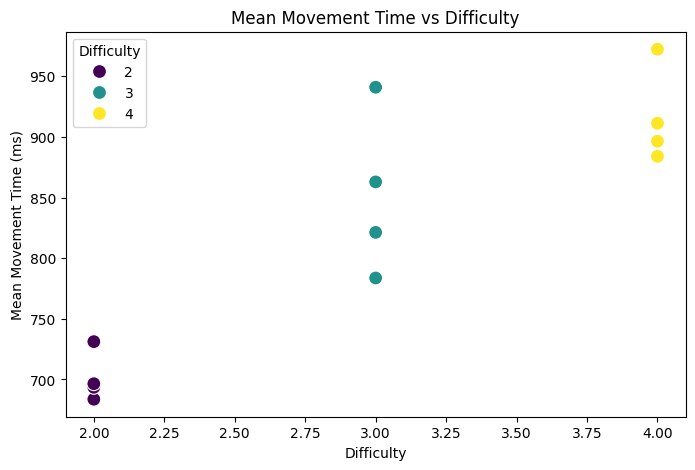

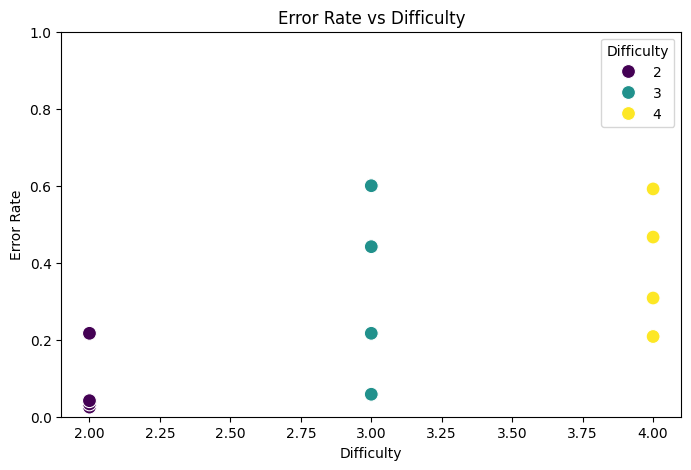

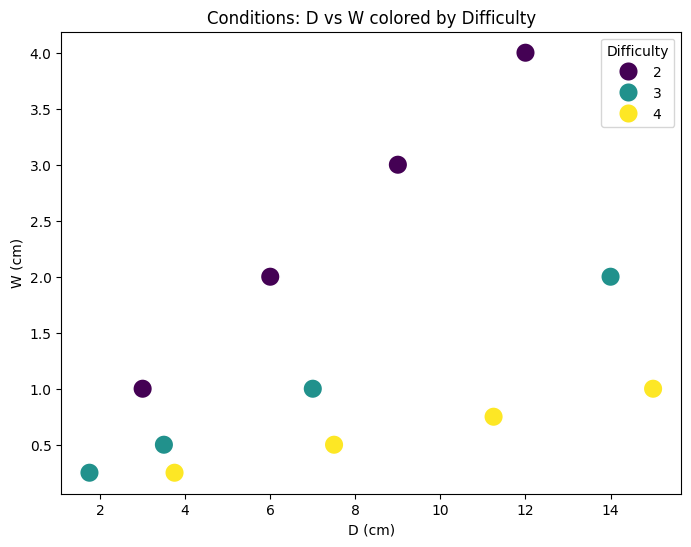

In [80]:
plot_summary(combined_summary)

#### Group 0

In [81]:
group_0_summary = create_summary(all_trials, 0)
group_0_summary

,D,W,difficulty_id,MT_mean,error_rate
0,1.75,0.25,3,974.980871,0.566667
1,3.00,1.00,2,761.897326,0.133333
2,3.50,0.50,3,891.203050,0.483333
3,3.75,0.25,4,961.873357,0.633333
4,6.00,2.00,2,700.300634,0.016667
5,7.00,1.00,3,842.692753,0.216667
6,7.50,0.50,4,923.663700,0.400000
7,9.00,3.00,2,706.165473,0.033333
8,11.25,0.75,4,927.904379,0.233333
9,12.00,4.00,2,744.174902,0.050000


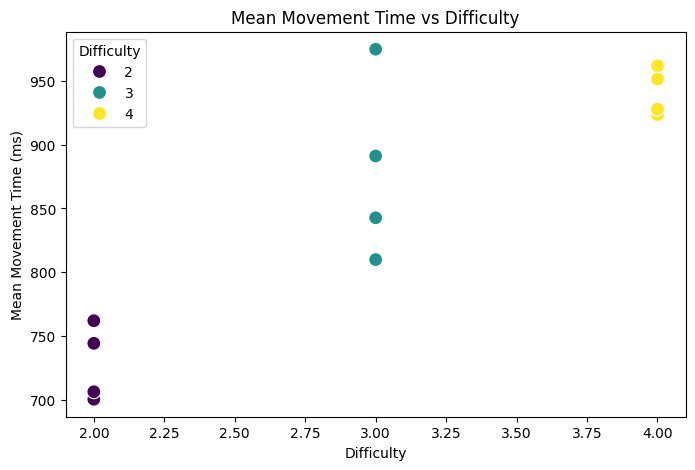

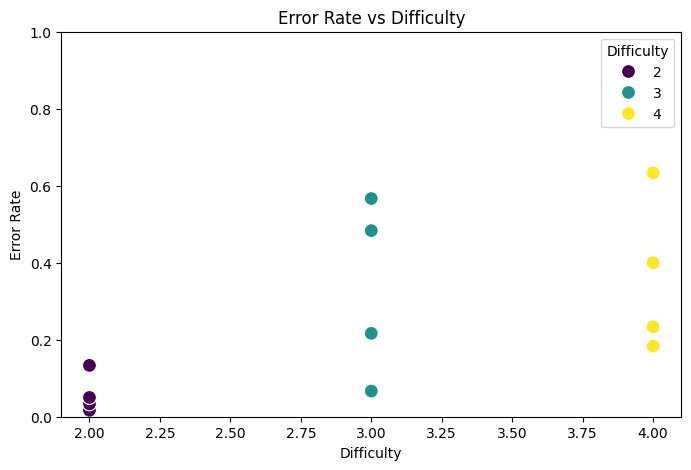

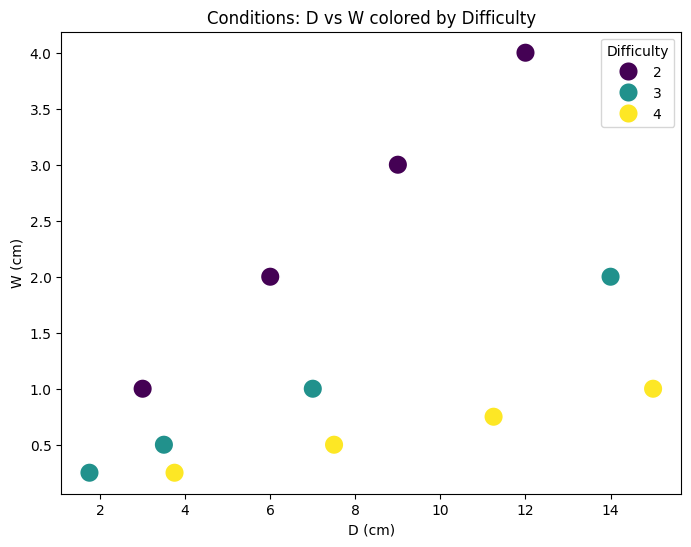

In [82]:
plot_summary(group_0_summary)

#### Group 1

In [83]:
group_1_summary = create_summary(all_trials, 1)
group_1_summary

,D,W,difficulty_id,MT_mean,error_rate
0,1.75,0.25,3,906.953696,0.633333
1,3.00,1.00,2,700.516037,0.300000
2,3.50,0.50,3,834.631884,0.400000
3,3.75,0.25,4,982.769469,0.550000
4,6.00,2.00,2,667.140802,0.033333
5,7.00,1.00,3,799.862770,0.216667
6,7.50,0.50,4,869.317492,0.533333
7,9.00,3.00,2,680.923494,0.033333
8,11.25,0.75,4,840.201747,0.383333
9,12.00,4.00,2,648.862974,0.033333


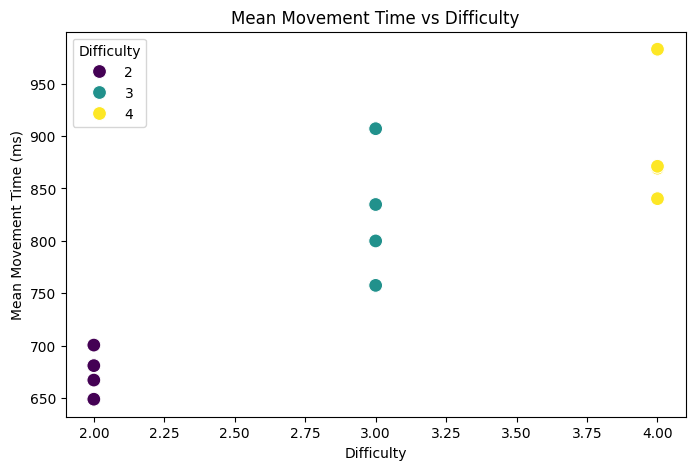

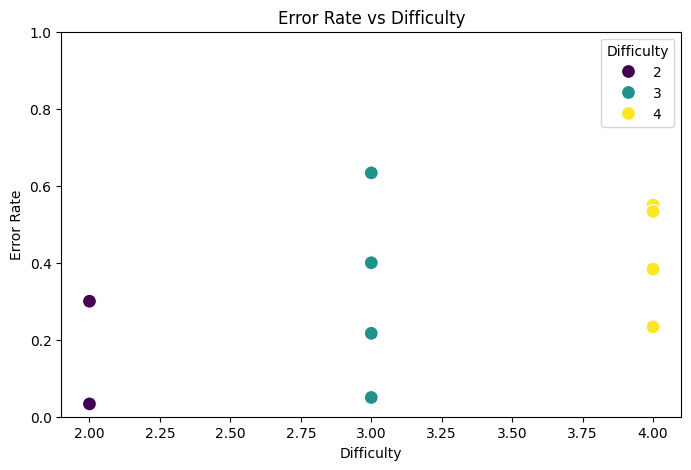

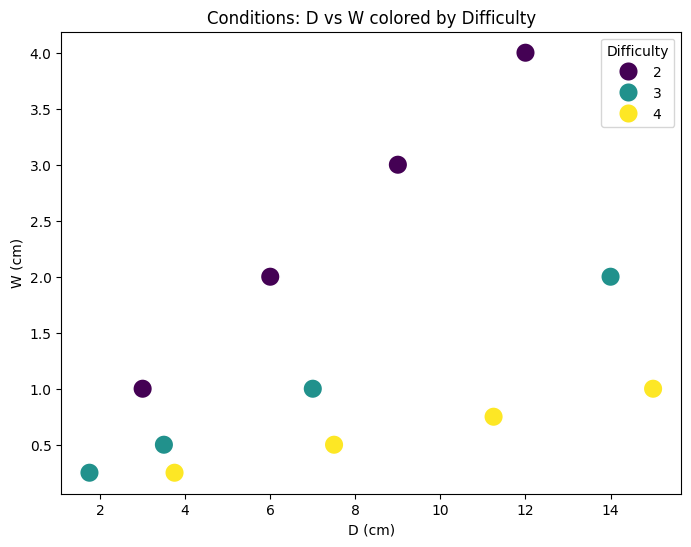

In [84]:
plot_summary(group_1_summary)